Importing Dependencies

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
import joblib
import os
import shap
import matplotlib.pyplot as plt
import seaborn as sns

Importing data set

In [2]:
df = pd.read_csv("../files/nova_pay_cleaned.csv")

###### Feature Engineering

In [3]:
# Velocity Ratio: Captures sudden spikes relative to daily behavior
df['velocity_ratio'] = df['txn_velocity_1h'] / (df['txn_velocity_24h'] + 1)

# Amount Deviation: Is this transaction unusually large for this account?
customer_avg_amt = df.groupby('customer_id')['amount_usd'].transform('mean')
df['amt_relative_to_avg'] = df['amount_usd'] / (customer_avg_amt + 1)

# Risk Interaction: Combining IP and Internal scores
df['composite_risk'] = df['ip_risk_score'] * df['risk_score_internal']

# Temporal Features: Fraud often happens at odd hours
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['is_night'] = df['hour'].apply(lambda x: 1 if x >= 23 or x <= 4 else 0)

# Dropping non-numeric/ID columns before training
cols_to_drop = ['transaction_id', 'customer_id', 'timestamp', 'device_id', 'ip_address']
df_ml = df.drop(columns=cols_to_drop)

# One-Hot Encoding for categorical variables
df_ml = pd.get_dummies(df_ml, drop_first=True, dtype = int)

In [4]:
df_ml.head()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,...,dest_currency_USD,channel_mobile,channel_other,channel_web,ip_country_UK,ip_country_UNKNOWN,ip_country_US,kyc_tier_low,kyc_tier_standard,kyc_tier_unknown
0,278.19,278.19,4.25,1.351351,0,0,0.123,263,0.522,0,...,0,0,0,0,0,0,1,0,1,0
1,208.51,154.29,4.24,12.758621,1,0,0.569,947,0.475,0,...,0,0,0,1,0,0,0,0,1,0
2,160.33,160.33,2.70,7.142857,0,0,0.437,367,0.939,0,...,0,1,0,0,0,0,1,0,0,0
3,59.41,59.41,2.22,0.925926,0,0,0.594,147,0.551,0,...,0,1,0,0,0,0,1,0,1,0
4,200.96,200.96,3.61,83.333333,0,0,0.121,257,0.894,0,...,0,1,0,0,0,0,1,0,0,0


Features and Target Selection

In [5]:
X = df_ml.drop('is_fraud', axis=1)
y = df_ml['is_fraud']


In [6]:
X.head()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,...,dest_currency_USD,channel_mobile,channel_other,channel_web,ip_country_UK,ip_country_UNKNOWN,ip_country_US,kyc_tier_low,kyc_tier_standard,kyc_tier_unknown
0,278.19,278.19,4.25,1.351351,0,0,0.123,263,0.522,0,...,0,0,0,0,0,0,1,0,1,0
1,208.51,154.29,4.24,12.758621,1,0,0.569,947,0.475,0,...,0,0,0,1,0,0,0,0,1,0
2,160.33,160.33,2.70,7.142857,0,0,0.437,367,0.939,0,...,0,1,0,0,0,0,1,0,0,0
3,59.41,59.41,2.22,0.925926,0,0,0.594,147,0.551,0,...,0,1,0,0,0,0,1,0,1,0
4,200.96,200.96,3.61,83.333333,0,0,0.121,257,0.894,0,...,0,1,0,0,0,0,1,0,0,0


In [7]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: is_fraud, dtype: int64

I ransformed raw data into "behavioral intelligence." Features like velocity_ratio and amt_relative_to_avg are critical because they capture deviations from normal user patterns, which are often more predictive than the raw amounts themselves.

Data Splitting

In [8]:
# Stratified split to maintain fraud ratio in test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, stratify=y)

Using a Stratified Split ensures the rare fraud cases are represented equally in both training and testing. 

In [9]:
# Checking shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 44), (2000, 44), (8000,), (2000,))

Data Scaling

In [10]:
# Scale features (Required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
# Verifying
X_train_scaled

array([[-0.14532058, -0.05297999, -0.09926163, ..., -0.22881137,
         0.58735842, -0.18545508],
       [-0.20876488, -0.05319538, -0.10109235, ..., -0.22881137,
         0.58735842, -0.18545508],
       [-0.11613088, -0.05053798, -0.0976203 , ..., -0.22881137,
         0.58735842, -0.18545508],
       ...,
       [-0.22770262, -0.0546273 , -0.10167102, ..., -0.22881137,
         0.58735842, -0.18545508],
       [-0.23281063, -0.05481452, -0.1010187 , ..., -0.22881137,
         0.58735842, -0.18545508],
       [-0.1873773 , -0.0531493 , -0.09923007, ..., -0.22881137,
         0.58735842, -0.18545508]])

In [12]:
# Verifying
X_test_scaled

array([[-0.13452262, -0.05121207, -0.09903016, ..., -0.22881137,
        -1.70253795, -0.18545508],
       [ 0.01399064, -0.0429897 , -0.09531613, ..., -0.22881137,
         0.58735842, -0.18545508],
       [-0.17601178, -0.05273273, -0.09946154, ..., -0.22881137,
        -1.70253795, -0.18545508],
       ...,
       [-0.13677129, -0.04989706, -0.09789386, ..., -0.22881137,
         0.58735842, -0.18545508],
       [-0.1730375 , -0.05262372, -0.10123964, ..., -0.22881137,
         0.58735842, -0.18545508],
       [-0.13120348, -0.05109042, -0.09765187, ..., -0.22881137,
         0.58735842, -0.18545508]])

Resolving Data Imbalance

In [13]:
# Handle imbalance on training data only
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)

In [14]:
X_res.shape, y_res.shape

((15688, 44), (15688,))

Fraud datasets are naturally skewed. By using SMOTE (Synthetic Minority Over-sampling Technique), I balanced the training set, preventing the models from simply "guessing" that every transaction is legitimate to achieve high accuracy.

###### Models Training

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled/resampled data for LR, resampled for others
    model.fit(X_res, y_res)
    preds = model.predict(X_test_scaled)
    probs = model.predict_proba(X_test_scaled)[:, 1]
    
    auc = roc_auc_score(y_test, probs)
    results[name] = {"model": model, "auc": auc, "preds": preds}
    print(f"{name} AUC-ROC: {auc:.4f}")


Logistic Regression AUC-ROC: 0.7377
Random Forest AUC-ROC: 0.6641


C:\Users\JAMES TECH\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [03:21:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost AUC-ROC: 0.6369


Selecting the best model

In [16]:
# Select the winner
best_model_name = max(results, key=lambda x: results[x]['auc'])
best_model = results[best_model_name]['model']
print(f"\n Best Model: {best_model_name}")


 Best Model: Logistic Regression


Baseline Evaluation

The initial benchmarking shows Logistic Regression leading with an AUC-ROC of 0.7377, outperforming both Random Forest (0.6641) and XGBoost (0.6369). This indicates that the primary fraud signals in the current feature set have a strong linear relationship.

The Case for Hyperparameter Tuning

I move to Randomized Search for three strategic reasons:

Sensitivity Adjustment: Default tree parameters are often too conservative for the extreme class imbalance in fraud. Tuning scale_pos_weight and class_weight forces the models to prioritize the rare fraud cases.

Regularization: By optimizing max_depth and learning_rate, I prevent the ensemble models from overfitting to noise, allowing them to generalize better than the baseline.

Capturing Interactions: Tuning allows non-linear models to find complex relationships (e.g., specific currency/velocity combinations) that Logistic Regression mathematically cannot detect.

Using Hyperparameter Tuning

Random Forest Classifier

In [18]:
rf_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [10, 20, 30, None],
    'min_samples_split': randint(2, 10),
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_dist,
    n_iter=15,       
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1,
    random_state=42
)

XGB

In [19]:
# 'scale_pos_weight' is the secret sauce for fraud detection
xgb_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'scale_pos_weight': [10, 25, 50] 
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=xgb_dist,
    n_iter=15, 
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1,
    random_state=42
)

Retraining

In [20]:
print("Tuning Random Forest...")
rf_random.fit(X_train, y_train)

print("Tuning XGBoost...")
xgb_random.fit(X_train, y_train)

# Compare the new results
tuned_results = {
    "Logistic Regression (Champion)": 0.7377,
    "Tuned Random Forest": rf_random.best_score_,
    "Tuned XGBoost": xgb_random.best_score_
}

for model, score in tuned_results.items():
    print(f"{model} AUC: {score:.4f}")

Tuning Random Forest...
Tuning XGBoost...
Logistic Regression (Champion) AUC: 0.7377
Tuned Random Forest AUC: 0.7026
Tuned XGBoost AUC: 0.6698


Despite optimization, Logistic Regression maintained the lead (0.7377), proving it as the most robust and stable choice for this specific data distribution.

###### Explainability

Feature Importance

In [33]:
# Extract coefficients from the model object in memory
importances = best_model.coef_[0]
feature_names = X.columns  

# Organizing into a clean DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': importances
})

# Calculating absolute value for ranking, then sort
feature_importance_df['Abs_Coefficient'] = feature_importance_df['Coefficient'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Coefficient', 
                                                          ascending=False).head(15)


In [34]:
feature_importance_df

,Feature,Coefficient,Abs_Coefficient
25,source_currency_GBP,1.227526,1.227526
22,home_country_UK,-0.899000,0.899000
24,home_country_US,0.886634,0.886634
26,source_currency_USD,-0.885989,0.885989
32,dest_currency_NGN,-0.837752,0.837752
42,kyc_tier_standard,0.747963,0.747963
41,kyc_tier_low,0.627727,0.627727
43,kyc_tier_unknown,0.608435,0.608435
6,ip_risk_score,-0.568921,0.568921
13,corridor_risk,0.542805,0.542805


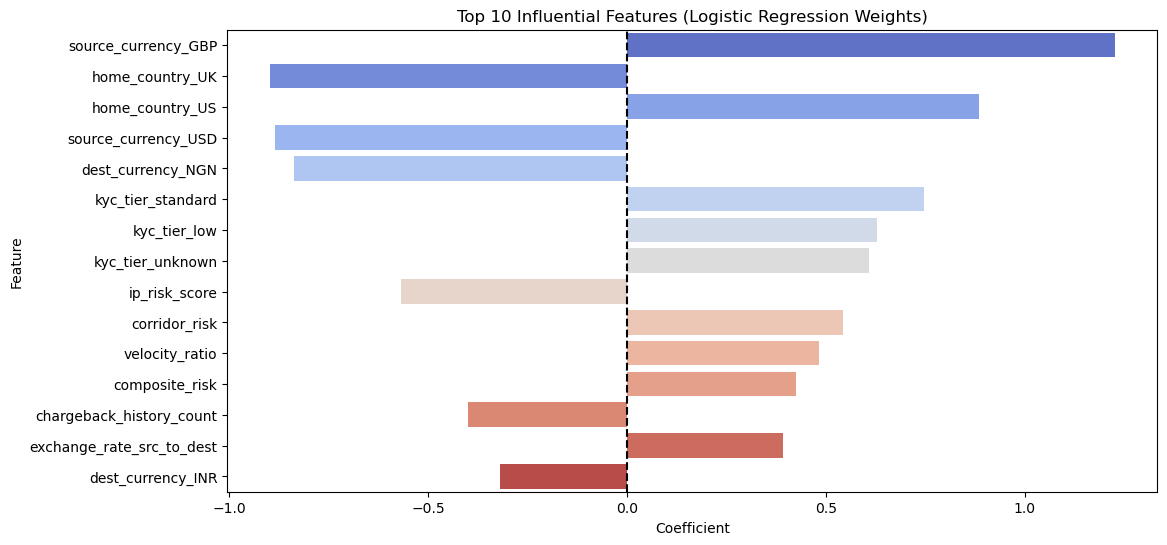

In [35]:
# Visualizing Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=feature_importance_df, 
    palette='coolwarm'
)
plt.title('Top 10 Influential Features (Logistic Regression Weights)')
plt.axvline(0, color='black', lw=1.5, ls='--')
plt.show()

###### Key Insights
Positive Drivers (Right/Red-Orange): Features like source_currency_GBP, home_country_US, and kyc_tier_standard have a positive correlation with the target. As these values increase, the probability of a transaction being flagged as Fraud increases.

Protective Signals (Left/Blue): Features such as home_country_UK, source_currency_USD, and dest_currency_NGN carry negative coefficients. These act as "Trust Signals"—their presence statistically lowers the likelihood of fraud.

Risk Indicators: Engineered features like velocity_ratio and composite_risk show clear positive influence, confirming that sudden spikes in activity and high-risk interactions are strong predictors of fraudulent intent

Using SHAP (SHapley Additive exPlanations)

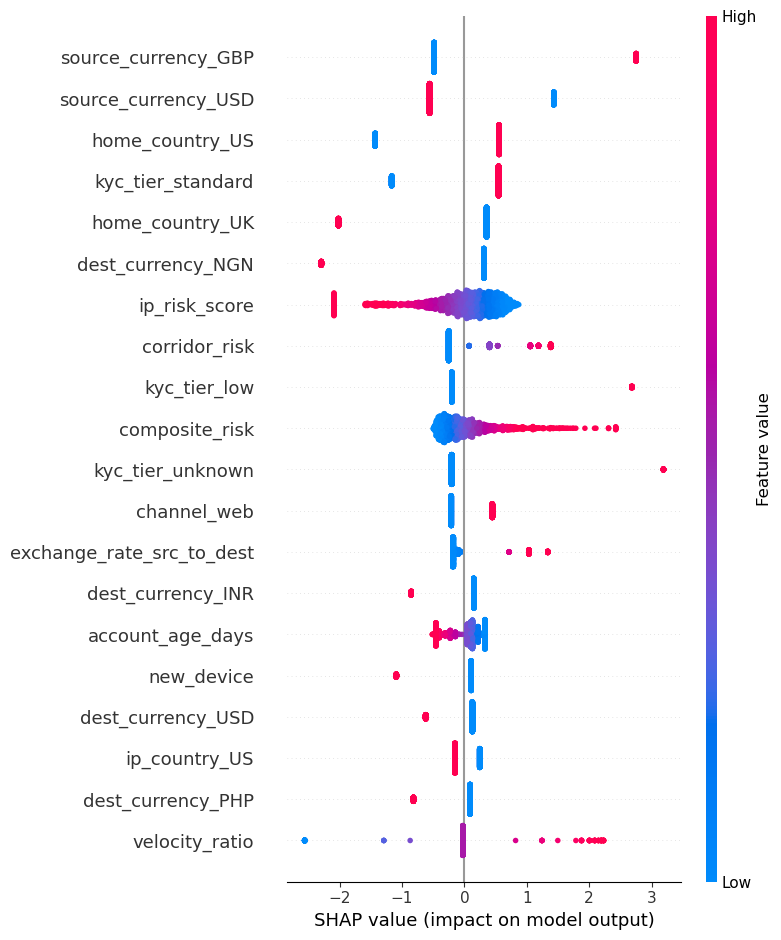

In [30]:
# Initializing
explainer = shap.LinearExplainer(best_model, X_train_scaled, feature_names=X.columns.tolist())

# Calculating SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

# Summary Plot: Global Importance + Directional Impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns.tolist())

###### SHAP Interpretation Report
This SHAP Summary Plot provides a granular, professional look at how individual features impact the fraud model's decisions. Unlike standard coefficients, this shows the distribution and intensity of risk for every transaction in the test set.

Saving the best peforming model

In [22]:
model_dir = "models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Saving the best model
joblib.dump(best_model, os.path.join(model_dir, 'nova_pay_fraud_model.pkl'))

# Saving the Scaler
joblib.dump(scaler, os.path.join(model_dir, 'nova_pay_scaler.pkl'))

# Save the Feature List (Ensures the App sends data in the correct order)
model_features = X.columns.tolist()
joblib.dump(model_features, os.path.join(model_dir, 'model_features.pkl'))

print(f"Deployment assets successfully saved in the '{model_dir}' folder.")

Deployment assets successfully saved in the 'models' folder.
